<a href="https://colab.research.google.com/github/xoxoreyniel/DSC1105/blob/main/DSC1105_SA1_Awit%2C_JT%3B_Deloyola%2C_JR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")
if (!require("corrplot")) install.packages("corrplot")

library(ggplot2)
library(dplyr)
library(corrplot)

df <- read.csv("/content/EDA_Ecommerce_Assessment.csv")

Unit 1: Univariate Data Analysis

[1] "Descriptive Statistics for Purchase Amount:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.03  128.69  245.09  247.96  367.20  499.61 


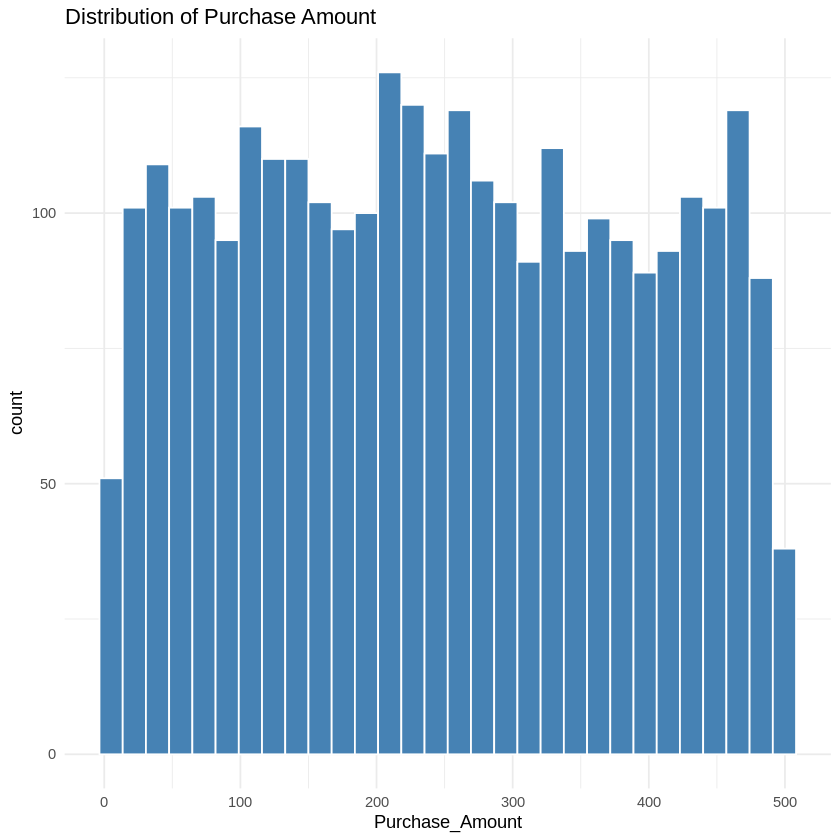

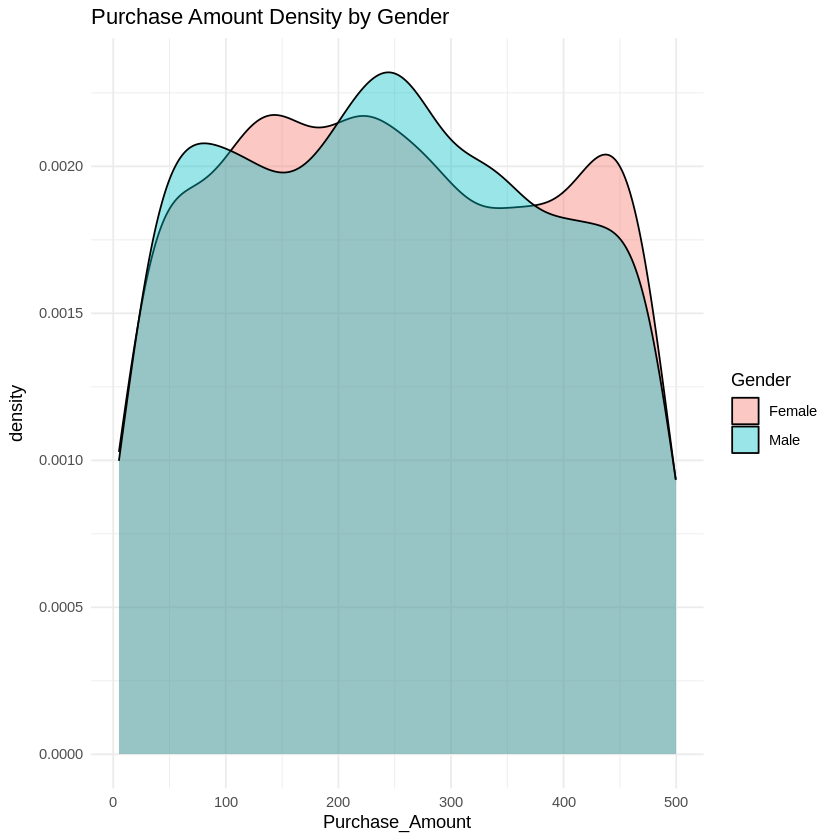

In [32]:
print("Descriptive Statistics for Purchase Amount:")
print(summary(df$Purchase_Amount))

# Histogram
ggplot(df, aes(x = Purchase_Amount)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 30) +
  labs(title = "Distribution of Purchase Amount") +
  theme_minimal()

# Density Plot by Gender
ggplot(df, aes(x = Purchase_Amount, fill = Gender)) +
  geom_density(alpha = 0.4) +
  labs(title = "Purchase Amount Density by Gender") +
  theme_minimal()

cat("\n")

Unit 2: Bivariate Data Analysis

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Linear R-Squared:  0.0003641881 
Polynomial R-Squared:  0.0004421741 


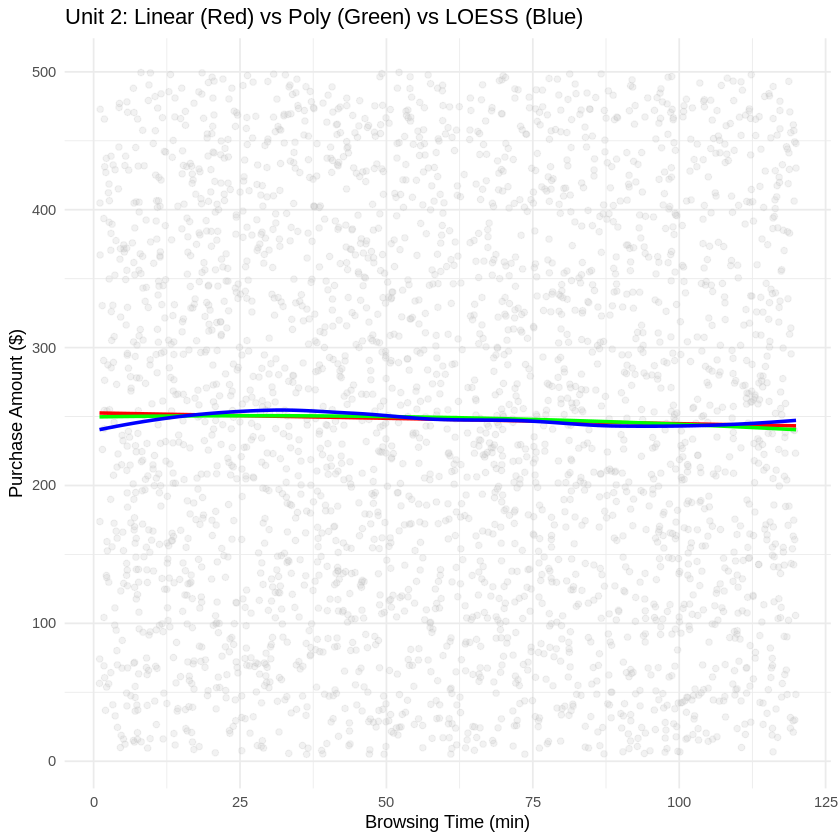

In [16]:
# Model Comparisons
ggplot(df, aes(x = Browsing_Time, y = Purchase_Amount)) +
  geom_point(alpha = 0.2, color = "gray") +
  # Linear Model (Red)
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  # Polynomial Model Degree 2 (Green)
  geom_smooth(method = "lm", formula = y ~ poly(x, 2), color = "green", se = FALSE) +
  # LOESS Smoothing (Blue)
  geom_smooth(method = "loess", color = "blue", se = FALSE) +
  labs(title = "Unit 2: Linear (Red) vs Poly (Green) vs LOESS (Blue)",
       x = "Browsing Time (min)", y = "Purchase Amount ($)") +
  theme_minimal()

# R-Squared for report
model_linear <- lm(Purchase_Amount ~ Browsing_Time, data = df)
model_poly <- lm(Purchase_Amount ~ poly(Browsing_Time, 2), data = df)
cat("Linear R-Squared: ", summary(model_linear)$r.squared, "\n")
cat("Polynomial R-Squared: ", summary(model_poly)$r.squared, "\n")

Unit 3: Trivariate/Hypervariate Data Analysis


Call:
lm(formula = Purchase_Amount ~ Age + Browsing_Time + Number_of_Items, 
    data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-249.039 -120.391   -3.292  118.454  253.751 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     253.63610   10.40835  24.369   <2e-16 ***
Age               0.06773    0.17198   0.394    0.694    
Browsing_Time    -0.07953    0.07505  -1.060    0.289    
Number_of_Items  -0.77471    1.00506  -0.771    0.441    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 140.9 on 2996 degrees of freedom
Multiple R-squared:  0.0006103,	Adjusted R-squared:  -0.0003904 
F-statistic: 0.6099 on 3 and 2996 DF,  p-value: 0.6086



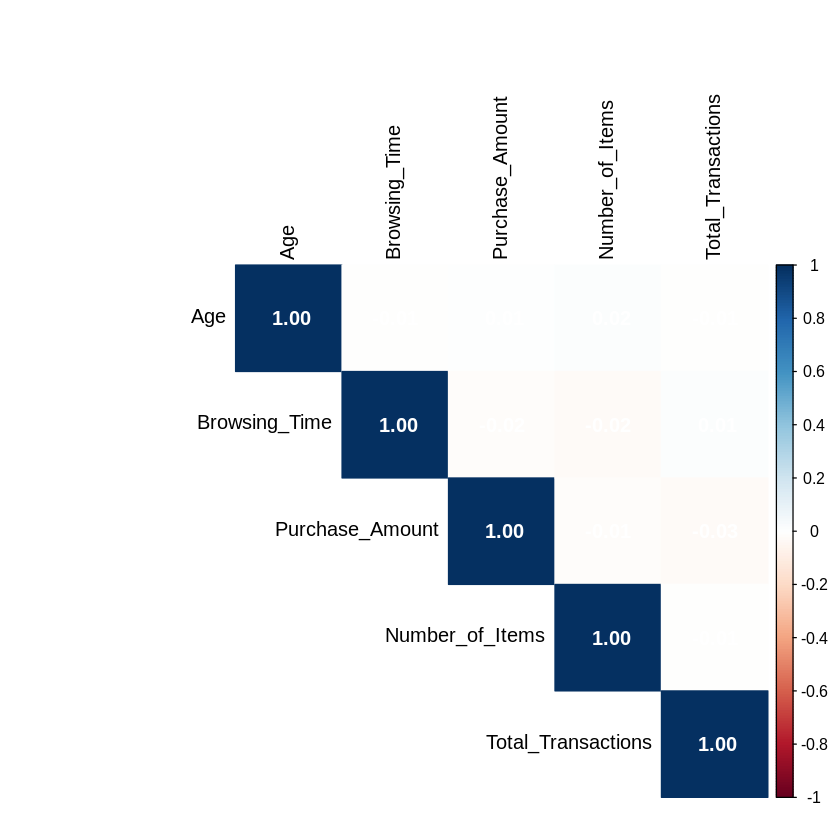

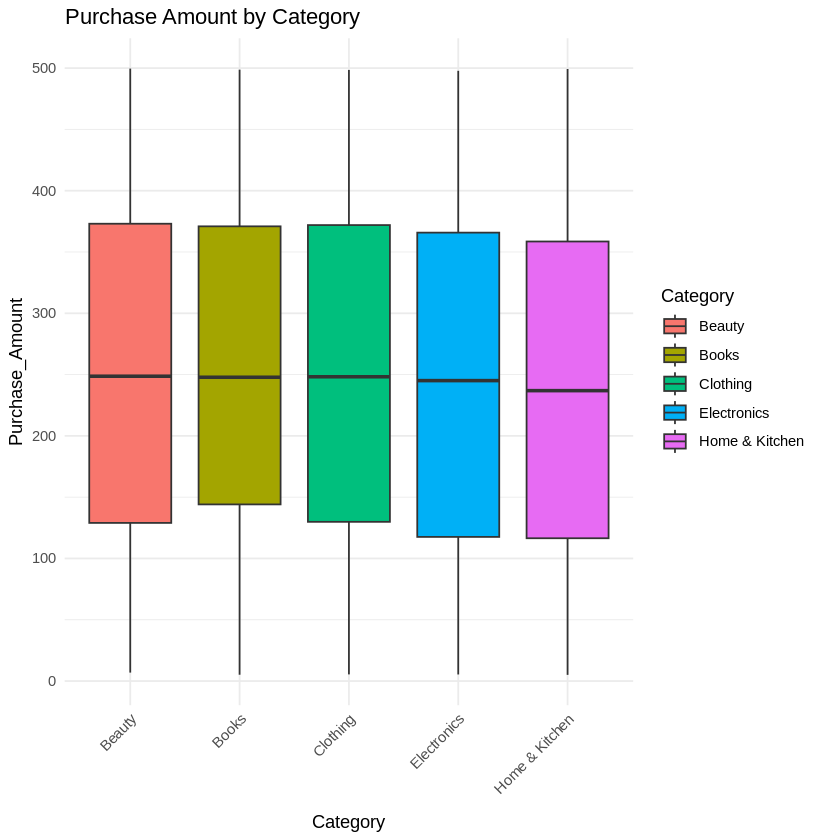

In [36]:
# Correlation Heatmap
numeric_cols <- df %>% select(Age, Browsing_Time, Purchase_Amount, Number_of_Items, Total_Transactions)
corr_matrix <- cor(numeric_cols)
corrplot(corr_matrix, method = "color", addCoef.col = "white", type = "upper", tl.col = "black")

# Multiple Linear Regression
multi_model <- lm(Purchase_Amount ~ Age + Browsing_Time + Number_of_Items, data = df)
print(summary(multi_model))

# Spending by Category
ggplot(df, aes(x = Category, y = Purchase_Amount, fill = Category)) +
  geom_boxplot() +
  labs(title = "Purchase Amount by Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

cat("\n")